# C08 – Decision Tree and KNN (M4)
**IT3051 Fundamentals of Data Mining – Mini Project 2026 – PE2 (modelling)**
**Task:** Classification – predict **`Late_delivery_risk`** (1 = late) at order placement.
**Owner:** M4

M4 trains **two models**: **Part A – Decision Tree** and **Part B – KNN**. Steps 1–2 run once; Steps 3–7 run once per model.

### Steps
1. Setup  2. Load data and team decisions  3. Choose the model  4. Default model  5. Tune  6. Compare  7. Save

### Rules
- Only the **training set** is used; the test set is used **once**, in C09.
- Same 5 grouped folds as the whole team. Main score: **ROC-AUC**; business priority: **recall**.
- While testing your code, set `N_ITER = 3`; set it back for the real run.

**Input:** `train_clf_fe.csv`, `clf_m3_selection.json`, `clf_m4_preprocessing.json`
**Output:** rows in `results/clf_experiments.csv`, `results/clf_params_<model>.json`, a chart in `reports/figures/clf_models/`

## Step 1 – Setup

The team's shared helpers for classification:
- `classification_metrics` – the 5 scores. **ROC-AUC** is the main score (how well late orders are separated from on-time ones);
  **recall** is the business priority (how many late orders are caught).
- `make_cv` – the 5 fair folds: orders stay together, same % of late orders in every fold.
- `cv_evaluate` – trains a fresh copy of the model on each fold, scores it, returns the averages and `roc_auc_std` (fold-to-fold noise).
- `log_experiment` – adds a result line to the shared `results/clf_experiments.csv`.
- `build_preprocessor` / `build_full_pipeline` – rebuild C03's encoding, add C04's scaler if needed, then the model – all in one pipeline.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import loguniform

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, TargetEncoder, StandardScaler, RobustScaler, MinMaxScaler
from sklearn.model_selection import StratifiedGroupKFold, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = ROOT / "data" / "processed"
RESULTS_DIR = ROOT / "results"
FIG_DIR = ROOT / "reports" / "figures" / "clf_models"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
TARGET, GROUP, SEED = "Late_delivery_risk", "Order Id", 42
METRICS = ["roc_auc", "accuracy", "precision", "recall", "f1"]
SCALERS = {"none": None, "standard": StandardScaler, "robust": RobustScaler, "minmax": MinMaxScaler}

def show(fig, name):
    fig.tight_layout(); fig.savefig(FIG_DIR / f"{name}.png", dpi=120); plt.show()

def classification_metrics(y_true, y_pred, y_proba):
    return {"roc_auc": roc_auc_score(y_true, y_proba),
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0)}

def make_cv(X, y, groups, n_splits=5, seed=SEED):
    return list(StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed).split(X, y, groups))

def cv_evaluate(pipe, X, y, cv_splits, return_proba=False):
    rows, oof = [], np.full(len(y), np.nan)
    for i, (tr, va) in enumerate(cv_splits):
        model = clone(pipe).fit(X.iloc[tr], y.iloc[tr])
        proba = model.predict_proba(X.iloc[va])[:, 1]
        oof[va] = proba
        rows.append({"fold": i, **classification_metrics(y.iloc[va], (proba >= 0.5).astype(int), proba)})
    per_fold = pd.DataFrame(rows)
    summary = {m: float(per_fold[m].mean()) for m in METRICS}
    summary["roc_auc_std"] = float(per_fold["roc_auc"].std())
    return (summary, per_fold, oof) if return_proba else (summary, per_fold)

def log_experiment(row, path=RESULTS_DIR / "clf_experiments.csv"):
    new = pd.DataFrame([row])
    out = pd.concat([pd.read_csv(path), new], ignore_index=True) if path.exists() else new
    out.to_csv(path, index=False)

def build_preprocessor(plan):
    parts = []
    if plan["numeric"]:
        parts.append(("num", SimpleImputer(strategy="median"), plan["numeric"]))
    if plan["onehot"]:
        parts.append(("onehot", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                                          ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), plan["onehot"]))
    if plan["onehot_rare"]:
        parts.append(("onehot_rare", OneHotEncoder(min_frequency=0.01, handle_unknown="infrequent_if_exist",
                                                   sparse_output=False), plan["onehot_rare"]))
    if plan["target"]:
        parts.append(("target", TargetEncoder(target_type="binary", random_state=SEED), plan["target"]))
    return ColumnTransformer(parts, remainder="drop")

def build_full_pipeline(model, plan, scaler="none"):
    steps = [("prep", build_preprocessor(plan))]
    if SCALERS[scaler] is not None:
        steps.append(("scale", SCALERS[scaler]()))
    steps.append(("model", model))
    return Pipeline(steps)

## Step 2 – Load the data and the team's decisions
Reads C03's features and encoding plan and C04's scaler choice and baseline. The printed baseline ROC-AUC is **the number to beat**.

In [2]:
m3 = json.loads((RESULTS_DIR / "clf_m3_selection.json").read_text(encoding="utf-8"))
FEATURES, PLAN, CATEGORY_COL = m3["features"], m3["plan"], m3["category_column"]
train = pd.read_csv(PROCESSED_DIR / "train_clf_fe.csv")
if CATEGORY_COL == "Category Id":
    train[CATEGORY_COL] = train[CATEGORY_COL].astype(str)
X, y, groups = train.drop(columns=[TARGET]), train[TARGET], train[GROUP]
cv_splits = make_cv(X, y, groups)

m4 = json.loads((RESULTS_DIR / "clf_m4_preprocessing.json").read_text(encoding="utf-8"))
fam = m4["scaler_by_model_family"]
LINEAR_SCALER = fam["linear (Logistic Regression)"]["scaler"]
KNN_SCALER = fam["distance (KNN)"]["scaler"]
MODE_BASELINE_AUC = m4["reference_cv_roc_auc"]["Baseline: Shipping Mode only"]
print(f"Train: {len(X):,} rows, late {y.mean() * 100:.1f}% | features: {FEATURES}")
print(f"Scaler for linear models: {LINEAR_SCALER} | for KNN: {KNN_SCALER}")
print(f"Shipping Mode baseline ROC-AUC to beat: {MODE_BASELINE_AUC}")

Train: 138,231 rows, late 57.2% | features: ['Shipping Mode', 'Market', 'Order Country', 'Category Name', 'Order Item Quantity', 'Customer Segment', 'order_weekday', 'order_month', 'order_hour', 'order_quarter', 'is_weekend']
Scaler for linear models: standard | for KNN: standard
Shipping Mode baseline ROC-AUC to beat: 0.7414


# Part A – Decision Tree

## Step 3 – Choose the model (Decision Tree)

**How it works:** yes/no questions ("Is it First Class?") until a group of similar orders is reached; the late share in that group is the answer.
**Scaling:** not needed. **Strength:** very easy to explain. **Weakness:** one deep tree overfits easily.
Settings: `max_depth`, `min_samples_leaf`, `min_samples_split`, `class_weight`.

In [3]:
from sklearn.tree import DecisionTreeClassifier

MODEL_NAME, OWNER = "DecisionTree", "M4"
MODEL = DecisionTreeClassifier(random_state=SEED)
SCALER = "none"
PARAMS = {"model__max_depth": [3, 5, 8, 10, 12, 15, 20, None], "model__min_samples_leaf": [1, 5, 10, 20, 50, 100],
          "model__min_samples_split": [2, 10, 50], "model__class_weight": [None, "balanced"]}
N_ITER = 30
SEARCH_JOBS = -1

## Step 4 – Score the model with default settings (Decision Tree)
Trains with normal settings on each fold and scores it – the **starting point**. Precision/recall/F1 use the usual 0.5 cut-off.

In [4]:
default_pipe = build_full_pipeline(MODEL, PLAN, SCALER)
default_scores, default_folds = cv_evaluate(default_pipe, X, y, cv_splits)
print(f"{MODEL_NAME} (default) - CV ROC-AUC {default_scores['roc_auc']:.4f} ± {default_scores['roc_auc_std']:.4f}")
default_folds.round(4)

DecisionTree (default) - CV ROC-AUC 0.6411 ± 0.0039


,fold,roc_auc,accuracy,precision,recall,f1
0,0,0.6372,0.6435,0.6945,0.6813,0.6879
1,1,0.6409,0.6482,0.6903,0.6963,0.6932
2,2,0.6439,0.6512,0.7008,0.6942,0.6975
3,3,0.6459,0.6507,0.6855,0.6956,0.6905
4,4,0.6375,0.6449,0.6880,0.6937,0.6908


## Step 5 – Tune the settings (Decision Tree)
`RandomizedSearchCV` tries `N_ITER` random combinations on the **same grouped folds** and keeps the best **ROC-AUC**.
- `val_AUC` – score on data the model did not learn from (**the one that matters**).
- `train_AUC` – score on data it learned from.
- `gap` = train − val. A **big gap = overfitting**.

`class_weight="balanced"` (where offered) makes the model pay more attention to the smaller class – it often raises recall.

In [5]:
X_tune, y_tune, tune_splits = X, y, cv_splits
if MODEL_NAME == "KNN":
    keep = pd.Series(groups.unique()).sample(frac=0.3, random_state=SEED)       # KNN is slow: tune on 30% of orders
    mask = groups.isin(keep).to_numpy()
    X_tune, y_tune = X[mask].reset_index(drop=True), y[mask].reset_index(drop=True)
    tune_splits = make_cv(X_tune, y_tune, groups[mask].reset_index(drop=True))

search = RandomizedSearchCV(build_full_pipeline(MODEL, PLAN, SCALER), PARAMS, n_iter=N_ITER, cv=tune_splits,
                            scoring="roc_auc", random_state=SEED, n_jobs=SEARCH_JOBS, return_train_score=True)
search.fit(X_tune, y_tune)
print("Best settings:", search.best_params_)
print(f"Best CV ROC-AUC during tuning: {search.best_score_:.4f}")

results = pd.DataFrame(search.cv_results_)
results["val_AUC"], results["train_AUC"] = results["mean_test_score"], results["mean_train_score"]
results["gap"] = results["train_AUC"] - results["val_AUC"]
results.sort_values("val_AUC", ascending=False)[["params", "val_AUC", "train_AUC", "gap"]].head(10).round(4)

Best settings: {'model__min_samples_split': 10, 'model__min_samples_leaf': 20, 'model__max_depth': 5, 'model__class_weight': 'balanced'}
Best CV ROC-AUC during tuning: 0.7761


,params,val_AUC,train_AUC,gap
7,"{'model__min_samples_split': 10, 'model__min_s...",0.7761,0.7836,0.0075
11,"{'model__min_samples_split': 2, 'model__min_sa...",0.7760,0.7838,0.0078
9,"{'model__min_samples_split': 2, 'model__min_sa...",0.7757,0.7906,0.0149
0,"{'model__min_samples_split': 2, 'model__min_sa...",0.7752,0.7918,0.0166
6,"{'model__min_samples_split': 10, 'model__min_s...",0.7752,0.7918,0.0166
3,"{'model__min_samples_split': 2, 'model__min_sa...",0.7750,0.7920,0.0170
4,"{'model__min_samples_split': 10, 'model__min_s...",0.7745,0.7913,0.0168
5,"{'model__min_samples_split': 2, 'model__min_sa...",0.7736,0.7795,0.0059
16,"{'model__min_samples_split': 50, 'model__min_s...",0.7736,0.7795,0.0059
25,"{'model__min_samples_split': 10, 'model__min_s...",0.7733,0.8106,0.0373


## Step 6 – Score the tuned model and compare (Decision Tree)
### 6.1 All scores: baseline vs default vs tuned

In [6]:
tuned_pipe = build_full_pipeline(MODEL, PLAN, SCALER).set_params(**search.best_params_)
tuned_scores, tuned_folds = cv_evaluate(tuned_pipe, X, y, cv_splits)
compare = pd.DataFrame({"Shipping Mode baseline": {"roc_auc": MODE_BASELINE_AUC},
                        f"{MODEL_NAME} default": default_scores,
                        f"{MODEL_NAME} tuned": tuned_scores}).T[METRICS + ["roc_auc_std"]]
compare.round(4)

,roc_auc,accuracy,precision,recall,f1,roc_auc_std
Shipping Mode baseline,0.7414,NaN,NaN,NaN,NaN,NaN
DecisionTree default,0.6411,0.6477,0.6918,0.6922,0.6920,0.0039
DecisionTree tuned,0.7761,0.7228,0.8937,0.5847,0.7069,0.0033


### 6.2 Chart and the two viva answers (Decision Tree)
**Did tuning help?** Real only if ROC-AUC improved by more than `roc_auc_std`. **Does the model beat the baseline?**

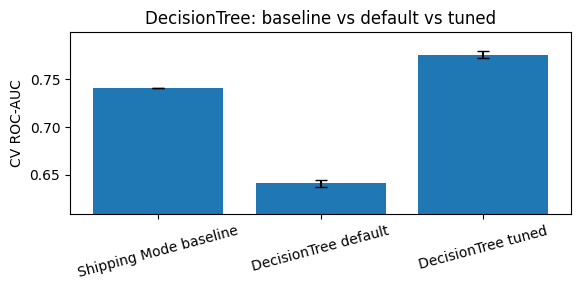

Tuning changed ROC-AUC by +0.1350 (fold noise ± 0.0033)
Improvement is real (bigger than the noise): True
Beats the Shipping Mode baseline: True


In [7]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(compare.index, compare["roc_auc"], yerr=compare["roc_auc_std"].fillna(0), capsize=4)
ax.set_ylabel("CV ROC-AUC"); ax.set_title(f"{MODEL_NAME}: baseline vs default vs tuned")
ax.set_ylim(compare["roc_auc"].min() * 0.95, min(1, compare["roc_auc"].max() * 1.03))
plt.xticks(rotation=15)
show(fig, f"{MODEL_NAME}_comparison")
change = tuned_scores["roc_auc"] - default_scores["roc_auc"]
print(f"Tuning changed ROC-AUC by {change:+.4f} (fold noise ± {tuned_scores['roc_auc_std']:.4f})")
print("Improvement is real (bigger than the noise):", change > tuned_scores["roc_auc_std"])
print("Beats the Shipping Mode baseline:", tuned_scores["roc_auc"] > MODE_BASELINE_AUC)

## Step 7 – Save the results (Decision Tree)
Adds the default and tuned results to `clf_experiments.csv` and saves `clf_params_<model>.json` – C09 reads these files.

In [8]:
for label, s in [("default", default_scores), ("tuned", tuned_scores)]:
    log_experiment({"owner": OWNER, "experiment": f"{MODEL_NAME}_{label}", "model": MODEL_NAME, "n_features": len(FEATURES),
                    **{m: s[m] for m in METRICS}, "roc_auc_std": s["roc_auc_std"]})
best_params = {k.replace("model__", ""): (v.item() if hasattr(v, "item") else v) for k, v in search.best_params_.items()}
summary = {"model": MODEL_NAME, "owner": OWNER, "scaler": SCALER, "best_params": best_params,
           "cv_roc_auc_default": round(default_scores["roc_auc"], 4), "cv_roc_auc_tuned": round(tuned_scores["roc_auc"], 4),
           "cv_roc_auc_std": round(tuned_scores["roc_auc_std"], 4),
           "cv_scores_tuned": {m: round(tuned_scores[m], 4) for m in METRICS}}
(RESULTS_DIR / f"clf_params_{MODEL_NAME}.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
print(json.dumps(summary, indent=2))

{
  "model": "DecisionTree",
  "owner": "M4",
  "scaler": "none",
  "best_params": {
    "min_samples_split": 10,
    "min_samples_leaf": 20,
    "max_depth": 5,
    "class_weight": "balanced"
  },
  "cv_roc_auc_default": 0.6411,
  "cv_roc_auc_tuned": 0.7761,
  "cv_roc_auc_std": 0.0033,
  "cv_scores_tuned": {
    "roc_auc": 0.7761,
    "accuracy": 0.7228,
    "precision": 0.8937,
    "recall": 0.5847,
    "f1": 0.7069
  }
}


### Summary (Decision Tree)

In [9]:
print(f"""
MODEL            {MODEL_NAME} ({OWNER}) | scaler {SCALER}
DEFAULT ROC-AUC  {default_scores['roc_auc']:.4f} ± {default_scores['roc_auc_std']:.4f}
TUNED ROC-AUC    {tuned_scores['roc_auc']:.4f} ± {tuned_scores['roc_auc_std']:.4f}
BASELINE         {MODE_BASELINE_AUC} (Shipping Mode) -> beaten: {tuned_scores['roc_auc'] > MODE_BASELINE_AUC}
TUNED AT 0.5     accuracy {tuned_scores['accuracy']:.3f} | precision {tuned_scores['precision']:.3f} | recall {tuned_scores['recall']:.3f} | F1 {tuned_scores['f1']:.3f}
BEST SETTINGS    {best_params}
""")


MODEL            DecisionTree (M4) | scaler none
DEFAULT ROC-AUC  0.6411 ± 0.0039
TUNED ROC-AUC    0.7761 ± 0.0033
BASELINE         0.7414 (Shipping Mode) -> beaten: True
TUNED AT 0.5     accuracy 0.723 | precision 0.894 | recall 0.585 | F1 0.707
BEST SETTINGS    {'min_samples_split': 10, 'min_samples_leaf': 20, 'max_depth': 5, 'class_weight': 'balanced'}



# Part B – KNN (k-nearest neighbours)

## Step 3 – Choose the model (KNN)

**How it works:** for a new order, find the **k most similar past orders**; the share of them that were late is the late probability.
**Scaling:** needed (C04 chose the scaler). **Weakness:** slow on big data, so tuning uses 30% of the orders; Step 6 uses all of them.
Settings: `n_neighbors` (k), `weights` (closer neighbours count more with `"distance"`), `p` (1 = Manhattan, 2 = Euclidean distance).

In [10]:
from sklearn.neighbors import KNeighborsClassifier

MODEL_NAME, OWNER = "KNN", "M4"
MODEL = KNeighborsClassifier(n_neighbors=15, n_jobs=-1)
SCALER = KNN_SCALER
PARAMS = {"model__n_neighbors": [5, 10, 15, 25, 50, 100], "model__weights": ["uniform", "distance"], "model__p": [1, 2]}
N_ITER = 15
SEARCH_JOBS = 1

## Step 4 – Score the model with default settings (KNN)
Trains with normal settings on each fold and scores it – the **starting point**. Precision/recall/F1 use the usual 0.5 cut-off.

In [11]:
default_pipe = build_full_pipeline(MODEL, PLAN, SCALER)
default_scores, default_folds = cv_evaluate(default_pipe, X, y, cv_splits)
print(f"{MODEL_NAME} (default) - CV ROC-AUC {default_scores['roc_auc']:.4f} ± {default_scores['roc_auc_std']:.4f}")
default_folds.round(4)

KNN (default) - CV ROC-AUC 0.7523 ± 0.0035


,fold,roc_auc,accuracy,precision,recall,f1
0,0,0.7533,0.6794,0.7521,0.6620,0.7042
1,1,0.7526,0.6804,0.7433,0.6725,0.7061
2,2,0.7488,0.6796,0.7493,0.6714,0.7082
3,3,0.7574,0.6850,0.7355,0.6835,0.7085
4,4,0.7493,0.6761,0.7393,0.6699,0.7029


## Step 5 – Tune the settings (KNN)
`RandomizedSearchCV` tries `N_ITER` random combinations on the **same grouped folds** and keeps the best **ROC-AUC**.
- `val_AUC` – score on data the model did not learn from (**the one that matters**).
- `train_AUC` – score on data it learned from.
- `gap` = train − val. A **big gap = overfitting**.

`class_weight="balanced"` (where offered) makes the model pay more attention to the smaller class – it often raises recall.

In [12]:
X_tune, y_tune, tune_splits = X, y, cv_splits
if MODEL_NAME == "KNN":
    keep = pd.Series(groups.unique()).sample(frac=0.3, random_state=SEED)       # KNN is slow: tune on 30% of orders
    mask = groups.isin(keep).to_numpy()
    X_tune, y_tune = X[mask].reset_index(drop=True), y[mask].reset_index(drop=True)
    tune_splits = make_cv(X_tune, y_tune, groups[mask].reset_index(drop=True))

search = RandomizedSearchCV(build_full_pipeline(MODEL, PLAN, SCALER), PARAMS, n_iter=N_ITER, cv=tune_splits,
                            scoring="roc_auc", random_state=SEED, n_jobs=SEARCH_JOBS, return_train_score=True)
search.fit(X_tune, y_tune)
print("Best settings:", search.best_params_)
print(f"Best CV ROC-AUC during tuning: {search.best_score_:.4f}")

results = pd.DataFrame(search.cv_results_)
results["val_AUC"], results["train_AUC"] = results["mean_test_score"], results["mean_train_score"]
results["gap"] = results["train_AUC"] - results["val_AUC"]
results.sort_values("val_AUC", ascending=False)[["params", "val_AUC", "train_AUC", "gap"]].head(10).round(4)

Best settings: {'model__weights': 'distance', 'model__p': 1, 'model__n_neighbors': 100}
Best CV ROC-AUC during tuning: 0.7546


,params,val_AUC,train_AUC,gap
8,"{'model__weights': 'distance', 'model__p': 1, ...",0.7546,0.9248,0.1701
1,"{'model__weights': 'uniform', 'model__p': 1, '...",0.7522,0.8257,0.0734
11,"{'model__weights': 'uniform', 'model__p': 1, '...",0.7513,0.8520,0.1007
6,"{'model__weights': 'distance', 'model__p': 1, ...",0.7509,0.9642,0.2133
3,"{'model__weights': 'uniform', 'model__p': 2, '...",0.7497,0.8154,0.0657
12,"{'model__weights': 'distance', 'model__p': 2, ...",0.7494,0.9409,0.1915
0,"{'model__weights': 'uniform', 'model__p': 1, '...",0.7451,0.8763,0.1311
5,"{'model__weights': 'distance', 'model__p': 1, ...",0.7440,0.9747,0.2307
4,"{'model__weights': 'distance', 'model__p': 2, ...",0.7437,0.9556,0.2119
14,"{'model__weights': 'uniform', 'model__p': 1, '...",0.7380,0.8988,0.1609


## Step 6 – Score the tuned model and compare (KNN)
### 6.1 All scores: baseline vs default vs tuned

In [13]:
tuned_pipe = build_full_pipeline(MODEL, PLAN, SCALER).set_params(**search.best_params_)
tuned_scores, tuned_folds = cv_evaluate(tuned_pipe, X, y, cv_splits)
compare = pd.DataFrame({"Shipping Mode baseline": {"roc_auc": MODE_BASELINE_AUC},
                        f"{MODEL_NAME} default": default_scores,
                        f"{MODEL_NAME} tuned": tuned_scores}).T[METRICS + ["roc_auc_std"]]
compare.round(4)

,roc_auc,accuracy,precision,recall,f1,roc_auc_std
Shipping Mode baseline,0.7414,NaN,NaN,NaN,NaN,NaN
KNN default,0.7523,0.6801,0.7439,0.6719,0.706,0.0035
KNN tuned,0.7602,0.7064,0.8260,0.6166,0.706,0.0040


### 6.2 Chart and the two viva answers (KNN)
**Did tuning help?** Real only if ROC-AUC improved by more than `roc_auc_std`. **Does the model beat the baseline?**

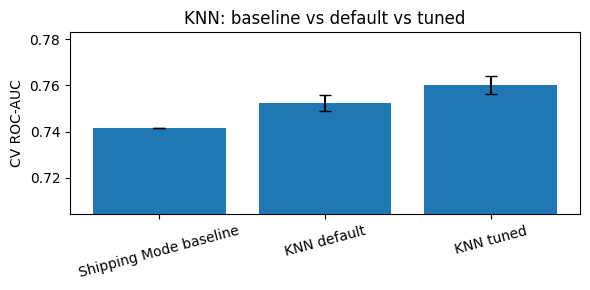

Tuning changed ROC-AUC by +0.0080 (fold noise ± 0.0040)
Improvement is real (bigger than the noise): True
Beats the Shipping Mode baseline: True


In [14]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(compare.index, compare["roc_auc"], yerr=compare["roc_auc_std"].fillna(0), capsize=4)
ax.set_ylabel("CV ROC-AUC"); ax.set_title(f"{MODEL_NAME}: baseline vs default vs tuned")
ax.set_ylim(compare["roc_auc"].min() * 0.95, min(1, compare["roc_auc"].max() * 1.03))
plt.xticks(rotation=15)
show(fig, f"{MODEL_NAME}_comparison")
change = tuned_scores["roc_auc"] - default_scores["roc_auc"]
print(f"Tuning changed ROC-AUC by {change:+.4f} (fold noise ± {tuned_scores['roc_auc_std']:.4f})")
print("Improvement is real (bigger than the noise):", change > tuned_scores["roc_auc_std"])
print("Beats the Shipping Mode baseline:", tuned_scores["roc_auc"] > MODE_BASELINE_AUC)

## Step 7 – Save the results (KNN)
Adds the default and tuned results to `clf_experiments.csv` and saves `clf_params_<model>.json` – C09 reads these files.

In [15]:
for label, s in [("default", default_scores), ("tuned", tuned_scores)]:
    log_experiment({"owner": OWNER, "experiment": f"{MODEL_NAME}_{label}", "model": MODEL_NAME, "n_features": len(FEATURES),
                    **{m: s[m] for m in METRICS}, "roc_auc_std": s["roc_auc_std"]})
best_params = {k.replace("model__", ""): (v.item() if hasattr(v, "item") else v) for k, v in search.best_params_.items()}
summary = {"model": MODEL_NAME, "owner": OWNER, "scaler": SCALER, "best_params": best_params,
           "cv_roc_auc_default": round(default_scores["roc_auc"], 4), "cv_roc_auc_tuned": round(tuned_scores["roc_auc"], 4),
           "cv_roc_auc_std": round(tuned_scores["roc_auc_std"], 4),
           "cv_scores_tuned": {m: round(tuned_scores[m], 4) for m in METRICS}}
(RESULTS_DIR / f"clf_params_{MODEL_NAME}.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
print(json.dumps(summary, indent=2))

{
  "model": "KNN",
  "owner": "M4",
  "scaler": "standard",
  "best_params": {
    "weights": "distance",
    "p": 1,
    "n_neighbors": 100
  },
  "cv_roc_auc_default": 0.7523,
  "cv_roc_auc_tuned": 0.7602,
  "cv_roc_auc_std": 0.004,
  "cv_scores_tuned": {
    "roc_auc": 0.7602,
    "accuracy": 0.7064,
    "precision": 0.826,
    "recall": 0.6166,
    "f1": 0.706
  }
}


### Summary (KNN)

In [16]:
print(f"""
MODEL            {MODEL_NAME} ({OWNER}) | scaler {SCALER}
DEFAULT ROC-AUC  {default_scores['roc_auc']:.4f} ± {default_scores['roc_auc_std']:.4f}
TUNED ROC-AUC    {tuned_scores['roc_auc']:.4f} ± {tuned_scores['roc_auc_std']:.4f}
BASELINE         {MODE_BASELINE_AUC} (Shipping Mode) -> beaten: {tuned_scores['roc_auc'] > MODE_BASELINE_AUC}
TUNED AT 0.5     accuracy {tuned_scores['accuracy']:.3f} | precision {tuned_scores['precision']:.3f} | recall {tuned_scores['recall']:.3f} | F1 {tuned_scores['f1']:.3f}
BEST SETTINGS    {best_params}
""")


MODEL            KNN (M4) | scaler standard
DEFAULT ROC-AUC  0.7523 ± 0.0035
TUNED ROC-AUC    0.7602 ± 0.0040
BASELINE         0.7414 (Shipping Mode) -> beaten: True
TUNED AT 0.5     accuracy 0.706 | precision 0.826 | recall 0.617 | F1 0.706
BEST SETTINGS    {'weights': 'distance', 'p': 1, 'n_neighbors': 100}



**My contribution in one sentence:** I trained and tuned the Decision Tree and KNN for late-delivery risk and compared each with its default settings and the Shipping Mode baseline.